In [1]:
# Task 3: Heart Disease Prediction
# Phase 1 - Load and Explore Dataset

import pandas as pd
import numpy as np

# Load dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=column_names, na_values="?")

# Basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values Per Column:")
print(df.isnull().sum())

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing Values Per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [3]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [4]:
# Phase 2 - Handle Missing Values

# Count missing values before handling
print("Missing values before:")
print(df.isnull().sum())

# Fill missing values with median (for numerical columns)
for col in ['ca', 'thal']:
    df[col].fillna(df[col].median(), inplace=True)

# Verify no missing values remain
print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


E:\Temp\ipykernel_10852\800802469.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
E:\Temp\ipykernel_10852\800802469.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never work

Target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


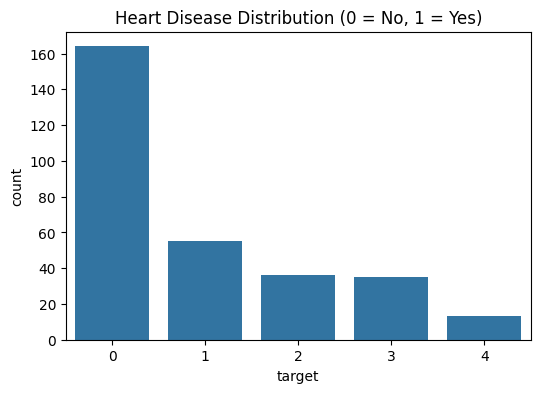

In [5]:
# Phase 3 - EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Check target variable distribution
print("Target distribution:")
print(df['target'].value_counts())

# Plot target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.show()

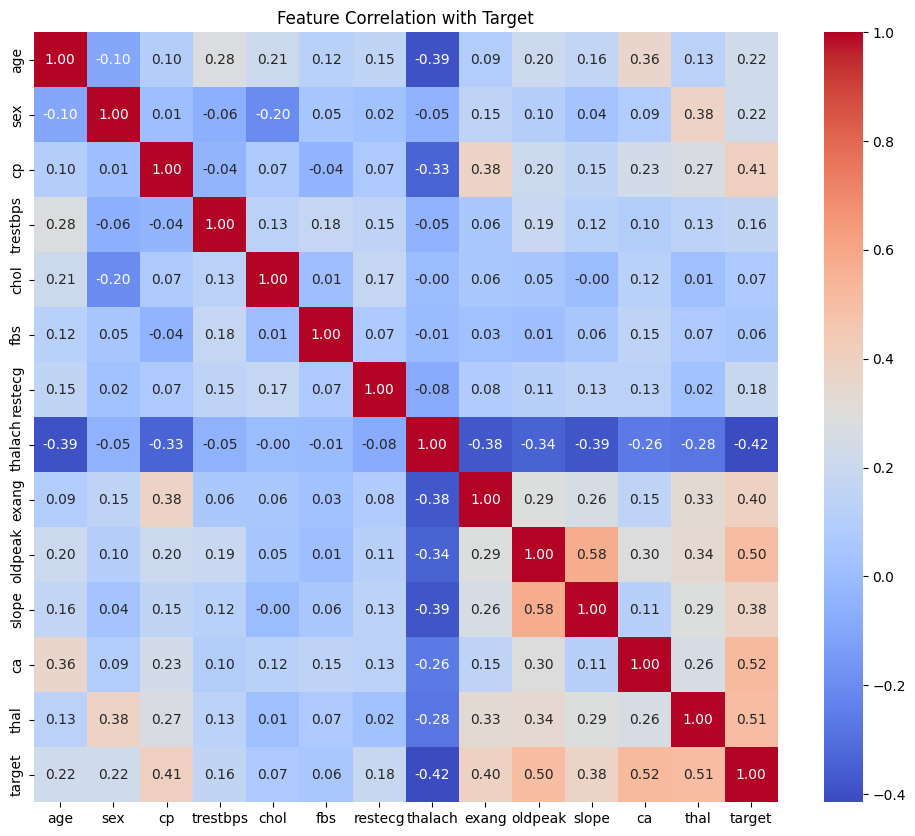

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Target')
plt.show()

In [7]:
# Phase 4 - Prepare Data for Modeling

# Define features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [8]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 242
Testing set size: 61


In [9]:
# Phase 5 - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [10]:
# Phase 5 - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [11]:
# Check data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nFirst few y_train values:")
print(y_train.head())

X_train shape: (242, 13)
y_train shape: (242,)
X_test shape: (61, 13)
y_test shape: (61,)

First few y_train values:
132    0
202    0
196    0
75     0
176    0
Name: target, dtype: int64


In [12]:
# Phase 5 - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [13]:
# Check unique values in target
print("Unique values in y_train:", y_train.unique())
print("Unique values in y_test:", y_test.unique())

Unique values in y_train: [0 3 1 2 4]
Unique values in y_test: [0 3 1 2 4]


In [14]:
# Convert to binary classification (0 = no disease, 1 = disease)
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

print("Original unique values:", y_train.unique())
print("Binary unique values:", y_train_binary.unique())

Original unique values: [0 3 1 2 4]
Binary unique values: [0 1]


In [15]:
# Train Logistic Regression on binary target
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train_binary)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test_binary, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_lr))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_lr))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [16]:
# Test with small sample
from sklearn.linear_model import LogisticRegression

# Take small sample for testing
X_sample = X_train.iloc[:10]
y_sample = y_train_binary.iloc[:10]

print("X_sample shape:", X_sample.shape)
print("y_sample values:", y_sample.values)

# Try to fit
test_model = LogisticRegression(max_iter=1000)
test_model.fit(X_sample, y_sample)
print("Test successful!")

X_sample shape: (10, 13)
y_sample values: [0 0 0 0 0 0 0 1 1 0]
Test successful!


In [17]:
# Train Logistic Regression on full dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create and train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train_binary)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
accuracy_lr = accuracy_score(y_test_binary, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_lr))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [18]:
# Check for infinity or missing values
print("Any infinity in X_train:", np.isinf(X_train).any().any())
print("Any NaN in X_train:", X_train.isnull().any().any())
print("Any infinity in y_train_binary:", np.isinf(y_train_binary).any())
print("Any NaN in y_train_binary:", y_train_binary.isnull().any())

Any infinity in X_train: False
Any NaN in X_train: True
Any infinity in y_train_binary: False
Any NaN in y_train_binary: False


In [19]:
# Remove rows with NaN in X_train and matching y_train
clean_mask = ~X_train.isnull().any(axis=1)
X_train_clean = X_train[clean_mask]
y_train_clean = y_train_binary[clean_mask]

# Also clean X_test
X_test_clean = X_test.dropna()

# Align y_test with cleaned X_test
y_test_clean = y_test_binary[X_test_clean.index]

print(f"Original X_train: {X_train.shape}")
print(f"Cleaned X_train: {X_train_clean.shape}")
print(f"Original X_test: {X_test.shape}")
print(f"Cleaned X_test: {X_test_clean.shape}")

Original X_train: (242, 13)
Cleaned X_train: (237, 13)
Original X_test: (61, 13)
Cleaned X_test: (60, 13)


In [20]:
# Train Logistic Regression on cleaned data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_clean, y_train_clean)

# Predict
y_pred_lr = lr_model.predict(X_test_clean)

# Accuracy
accuracy_lr = accuracy_score(y_test_clean, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clean, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test_clean, y_pred_lr))

Logistic Regression Accuracy: 0.8833

Confusion Matrix:
[[25  4]
 [ 3 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.90      0.89        31

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [21]:
# Phase 6 - Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_clean, y_train_clean)

# Predict
y_pred_dt = dt_model.predict(X_test_clean)

# Accuracy
accuracy_dt = accuracy_score(y_test_clean, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clean, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test_clean, y_pred_dt))

Decision Tree Accuracy: 0.7667

Confusion Matrix:
[[26  3]
 [11 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.90      0.79        29
           1       0.87      0.65      0.74        31

    accuracy                           0.77        60
   macro avg       0.79      0.77      0.76        60
weighted avg       0.79      0.77      0.76        60



Top 5 Most Important Features for Heart Disease Prediction:
1. ca: 1.2488
2. sex: 1.1764
3. fbs: 0.7543
4. exang: 0.6979
5. slope: 0.5677


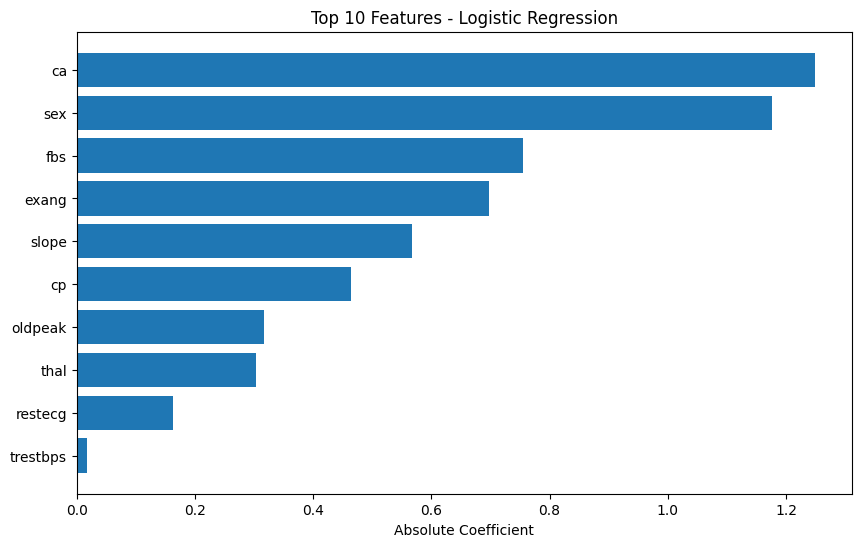

In [22]:
# Phase 7 - Feature Importance
import matplotlib.pyplot as plt

# Get feature importance from Logistic Regression
feature_importance = abs(lr_model.coef_[0])
feature_names = X_train_clean.columns

# Sort by importance
sorted_idx = np.argsort(feature_importance)[::-1]

print("Top 5 Most Important Features for Heart Disease Prediction:")
for i in range(5):
    print(f"{i+1}. {feature_names[sorted_idx[i]]}: {feature_importance[sorted_idx[i]]:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(10), feature_importance[sorted_idx[:10]][::-1])
plt.yticks(range(10), [feature_names[i] for i in sorted_idx[:10]][::-1])
plt.xlabel('Absolute Coefficient')
plt.title('Top 10 Features - Logistic Regression')
plt.show()